# KNN with Three Features on a Self-Made Synthetic Dataset

This notebook uses a small dataset generated for this exercise. It has three numeric inputs: `radius_like`, `texture_like`, and `concavity_like`, and a binary label (`B` or `M`). The values are simulated from different class-conditional distributions; they are not observations from patients and are not suitable for medical conclusions.

The classifier is K-Nearest Neighbors with **Euclidean distance**. The features are standardized before distance calculations, and accuracy is calculated on a held-out test set.


## 1. Load the synthetic data

Add `synthetic_three_feature_dataset.csv` as a Kaggle input. The search below finds it automatically. The CSV is also included alongside this notebook.

In [1]:
from pathlib import Path
import pandas as pd

candidates = list(Path('/kaggle/input').rglob('synthetic_three_feature_dataset.csv')) if Path('/kaggle/input').exists() else []
if not candidates:
    candidates = list(Path('.').rglob('synthetic_three_feature_dataset.csv'))
if not candidates:
    raise FileNotFoundError('Add synthetic_three_feature_dataset.csv as a Kaggle input.')
df = pd.read_csv(candidates[0])
display(df.head())
print('Rows and columns:', df.shape)
print('Features:', ['radius_like', 'texture_like', 'concavity_like'])
print('Class counts:')
display(df['diagnosis'].value_counts())

,sample_id,diagnosis,radius_like,texture_like,concavity_like
0,1,B,16.94434,18.19219,0.03616
1,2,M,18.17987,16.73223,0.15110
2,3,B,10.74607,14.52125,0.08708
3,4,M,18.16088,16.56252,0.23063
4,5,B,10.25929,13.23945,0.06185


Rows and columns: (600, 5)
Features: ['radius_like', 'texture_like', 'concavity_like']
Class counts:


diagnosis
B    300
M    300
Name: count, dtype: int64

## 2. Explore the three features

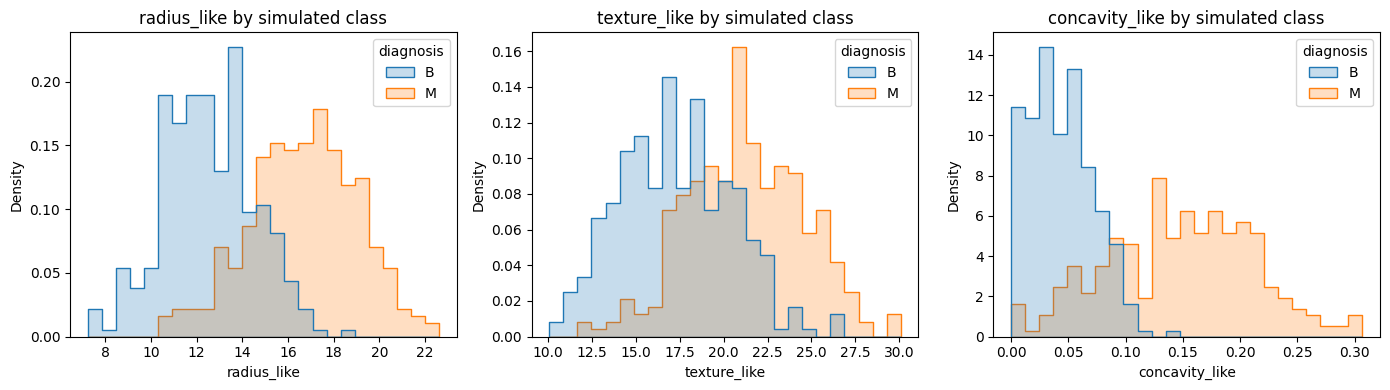

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, ['radius_like', 'texture_like', 'concavity_like']):
    sns.histplot(data=df, x=feature, hue='diagnosis', element='step', stat='density',
                 common_norm=False, bins=25, ax=ax)
    ax.set_title(f'{feature} by simulated class')
plt.tight_layout()
plt.show()

## 3. Split, scale, and fit KNN

Every fifth row is held out for testing; the remaining rows train the model. This deterministic split makes the supplied CSV and notebook results reproducible. StandardScaler is fitted on training data only.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

feature_names = ['radius_like', 'texture_like', 'concavity_like']
X = df[feature_names]
y = df['diagnosis'].map({'B': 0, 'M': 1})
test_mask = (df.index % 5 == 0)
X_train, X_test = X.loc[~test_mask], X.loc[test_mask]
y_train, y_test = y.loc[~test_mask], y.loc[test_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {accuracy:.4f} ({accuracy:.1%})')
print('Test samples:', len(y_test))
print('\nClassification report (0 = B, 1 = M):')
print(classification_report(y_test, y_pred, target_names=['Benign-like (B)', 'Malignant-like (M)']))

Test accuracy: 0.9500 (95.0%)
Test samples: 120

Classification report (0 = B, 1 = M):
                    precision    recall  f1-score   support

   Benign-like (B)       0.94      0.97      0.95        60
Malignant-like (M)       0.97      0.93      0.95        60

          accuracy                           0.95       120
         macro avg       0.95      0.95      0.95       120
      weighted avg       0.95      0.95      0.95       120



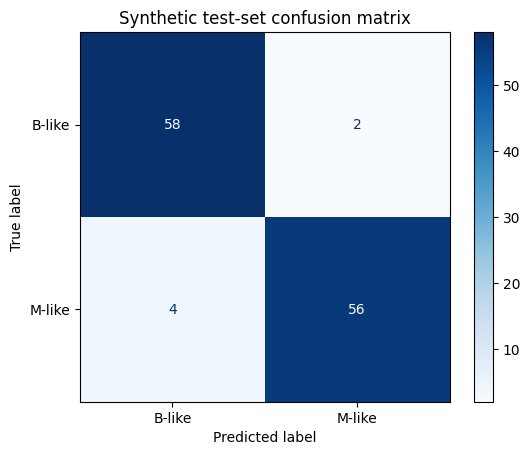

In [4]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=['B-like', 'M-like']).plot(cmap='Blues', values_format='d')
plt.title('Synthetic test-set confusion matrix')
plt.show()

## 4. Interpretation

The accuracy above measures how often the model predicted the generated labels correctly on the held-out synthetic rows. It describes only this artificial dataset and split. It does not estimate performance on real patient data or support medical diagnosis.
